# MSc AI Capstone 5 — Generative AI Applications
## Conditional Generation of HKDSE ICT Multiple-Choice Questions with a Fine-Tuned Transformer (TinyLlama-1.1B + LoRA)

| Task | Section |
|---|---|
| 1 | Define the generative task, approach and data source |
| 2 | Load and inspect the data |
| 3 | Implement and train the generative model |
| 4 | Generate and evaluate outputs |
| 5 | Notebook summary |
| 7 | Reproducibility (`requirements.txt`) |

*(Task 6 is the separate PDF report.)*

In [1]:
# =============================================================================
# SETUP: environment, imports, random seed and device check
# -----------------------------------------------------------------------------
# Output: libraries imported; SEED and device defined (both are used by later cells).
# =============================================================================

# Kaggle only: the preinstalled torchao is older than what the installed transformers/peft expect.
# Harmless "Failed to load ... .so" warnings may be printed afterwards; they can be ignored.
!pip install --upgrade torchao

import warnings
warnings.filterwarnings('ignore')            # keep the notebook output readable

import os, re, sys, subprocess               # file paths, regular expressions, pip freeze (Task 7)

import numpy as np                           # numerical arrays
import pandas as pd                          # tabular data
import matplotlib.pyplot as plt              # plotting
import seaborn as sns                        # statistical plots
import torch                                 # deep-learning framework (PyTorch)

from transformers import (AutoTokenizer, AutoModelForCausalLM, Trainer,
                          TrainingArguments, DataCollatorForLanguageModeling, set_seed)  # model, tokenizer, training loop
from datasets import Dataset                 # Hugging Face dataset wrapper used by the Trainer
from peft import LoraConfig, get_peft_model  # LoRA adapters (parameter-efficient fine-tuning)
from sklearn.model_selection import train_test_split          # stratified train/validation split
from sklearn.feature_extraction.text import TfidfVectorizer   # TF-IDF vectors for the module-consistency check
from sklearn.metrics.pairwise import cosine_similarity        # similarity between two texts

SEED = 42                                    # one seed for the split, sampling and training (reproducibility)
set_seed(SEED)
sns.set_theme(style='whitegrid')

# Task instructions: confirm that PyTorch can detect the device
device = "cuda" if torch.cuda.is_available() else "cpu"
print('Imports OK | torch', torch.__version__, '| device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
device

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so


Imports OK | torch 2.11.0+cu128 | device: cuda
GPU: Tesla T4


'cuda'

---
# Task 1 — Define the Generative Task and Select Your Approach

**Goal.** Build a *conditional text generator* that writes new, exam-style multiple-choice questions (MCQs) for HKDSE ICT Paper 1A. The user chooses a curriculum module and a question-type code (for example `a_ip_03` = Module A, *Information Processing*) and the model writes a question.

**Content produced.** One question stem plus four options (A–D), in the same plain-text / Markdown layout as the real papers. The answer key is *not* generated (see limitations).

**Approach: Transformer-based generation** (decoder-only causal language model).
- The task is text-sequence generation, which is exactly what an autoregressive Transformer language model does (GANs and VAEs are used here for images, not text).
- **Model:** `TinyLlama/TinyLlama-1.1B-Chat-v1.0`, a 22-layer LLaMA-architecture decoder. It is already pre-trained on general English text, so it only has to learn the *format and content style* of ICT exam questions, and at 1.1B parameters it fits on a single free GPU.
- **Fine-tuning:** LoRA (low-rank adapters). Only a small fraction of weights is trained, which suits a small dataset (~450 training examples) and reduces over-fitting and forgetting.
- **Conditioning:** every training example starts with a header (`Module: ...` / `Type: ...`) built from the dataset's `qn_type_id`. At generation time only the header is supplied and the model writes the question and options.

**Data source and documentation**
- **Source:** HKEAA HKDSE ICT Paper 1A (multiple-choice) past papers, 2012–2025: 14 papers × 40 questions = 560 questions. The papers are published by the Hong Kong Examinations and Assessment Authority.
- **How it was obtained:** the paper PDFs were converted to Markdown and structured into one CSV row per question (`final_dataset.csv`: question text, options, answer key, image references, cohort percentage). Each question was classified against the topic taxonomy of the official *ICT Curriculum and Assessment Guide (Secondary 4–6)* (modules A–E). Field definitions are in `fields_explanation.md`.
- **Requirement check:** real questions written by human exam setters (not synthetic or AI-generated); created for this capstone (not reused from an earlier project); used for non-commercial academic study only (the questions remain HKEAA material).
- **How it is used:** only the module/type header, question stem and options are used for training. Figures are *not* visible to the text model (see preprocessing notes in Task 2).

---
# Task 2 — Load and Inspect the Data

## 2.1 Load the dataset
The cell below finds the CSV on Kaggle or locally (`/data`).

In [ ]:
# =============================================================================
# KAGGLE ONLY: copy the dataset files from the read-only input folder to the
# working folder. Not needed on a local machine (the next cell finds the CSV).
# =============================================================================
#Kaggle only: 
#Create a folder under /kaggle/working/
!mkdir -p /kaggle/working/data

# Copy files to /working
!cp /kaggle/input/datasets/stansir/dataset/final_dataset.csv /kaggle/working/data/
!cp /kaggle/input/datasets/stansir/dataset/ict_curriculum.md /kaggle/working/data/

In [7]:
# =============================================================================
# TASK 2.1 - Load the dataset
# -----------------------------------------------------------------------------
# Input : final_dataset.csv (one row per HKDSE ICT Paper 1A multiple-choice question)
# Output: DataFrame `df` (560 rows x 11 columns) and the path actually used (DATA_PATH)
# =============================================================================

# Places where the CSV may be: Kaggle working copy, Kaggle input, or a local folder.
CANDIDATE_PATHS = [
    '/kaggle/working/data/final_dataset.csv',
    '/kaggle/input/datasets/stansir/dataset/final_dataset.csv',
    '/data/final_dataset.csv',
    'data/final_dataset.csv',
    'final_dataset.csv',
]

# Use the first path that exists; fail early with a clear message if none does.
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError('final_dataset.csv not found. Looked in: ' + ', '.join(CANDIDATE_PATHS))

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} questions from {DATA_PATH}')
print('Shape:', df.shape)

Loaded 560 questions from /kaggle/working/data/final_dataset.csv
Shape: (560, 11)


## 2.2 Inspect structure, formats and sizes

In [8]:
# =============================================================================
# TASK 2.2 - Inspect structure, formats and sizes
# -----------------------------------------------------------------------------
# Output: CORE_NAMES (module letter -> module name) and a new column df['core']
#         (A-E = curriculum module, U = unclassified), plus summary printouts.
# =============================================================================

# The five compulsory modules of the HKDSE ICT curriculum
CORE_NAMES = {
    'A': 'Information Processing',
    'B': 'Computer System Fundamentals',
    'C': 'Internet and Its Applications',
    'D': 'Computational Thinking and Programming',
    'E': 'Social Implications',
}

# qn_type_id can hold several types separated by ';' and 79 questions are 'unclassified'.
# The module is taken from the FIRST type id; its first letter (a-e) is the module.
first_type = df['qn_type_id'].str.split(';').str[0].str.strip()
df['core'] = first_type.str[0].str.upper().where(first_type != 'unclassified', 'U')   # U = unclassified

# Column overview: data type, number of non-missing values, number of distinct values
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'non-null': df.notna().sum(), 'unique': df.nunique()}))

# Dataset facts that drive the preprocessing decisions in section 2.4
print('\nPapers   :', df['paper_year'].min(), '-', df['paper_year'].max(), f"({df['paper_year'].nunique()} papers)")
print('Per core :', df['core'].value_counts().sort_index().to_dict(), '(U = unclassified)')
print('Questions with several type ids :', int(df['qn_type_id'].str.contains(';').sum()))
print('Questions with a body image     :', int(df['qn_image_filename'].notna().sum()))
print('Options that are images only    :', int((df['answer_options'].str.strip() == '[IMAGE]').sum()))
print('Answer key distribution         :', df['correct_answer'].value_counts().to_dict(), "('*' = withdrawn)")

# Size of one question in characters (stem + options)
chars = df['question_text'].str.len() + df['answer_options'].str.len()
print('\nCharacters per question (stem + options):')
print(chars.describe().round(1).to_string())

,dtype,non-null,unique
qn_type_id,object,560,60
qn_id,object,560,560
paper_year,int64,560,14
question_text,object,560,560
qn_image_filename,object,145,145
qn_image_type,object,145,7
qn_image_context,object,145,63
ans_image_filename,object,5,5
answer_options,object,560,334
correct_answer,object,560,5



Papers   : 2012 - 2025 (14 papers)
Per core : {'A': 154, 'B': 84, 'C': 119, 'D': 74, 'E': 50, 'U': 79} (U = unclassified)
Questions with several type ids : 61
Questions with a body image     : 145
Options that are images only    : 3
Answer key distribution         : {'B': 144, 'A': 141, 'C': 138, 'D': 136, '*': 1} ('*' = withdrawn)

Characters per question (stem + options):
count    560.0
mean     317.6
std      100.0
min       63.0
25%      251.8
50%      313.5
75%      377.2
max      654.0


## 2.3 Representative samples (one per module, plus one question that uses a figure)

In [9]:
# =============================================================================
# TASK 2.3 - Representative samples
# -----------------------------------------------------------------------------
# Prints one random question per module (A-E) and one question that uses a figure.
# =============================================================================

def show(row, label):
    """Print one question (identifiers, stem and options) in a readable block.

    Args:
        row (pd.Series): one row of the dataset.
        label (str): heading shown before the question id, e.g. 'Module A - Information Processing'.
    """
    print('=' * 78)
    print(f"{label} | {row['qn_id']} | type: {row['qn_type_id']} | key: {row['correct_answer']}")
    print('-' * 78)
    print(row['question_text'].strip())
    print()
    print(row['answer_options'].strip())

# One reproducible random question from each module
for c in 'ABCDE':
    show(df[df['core'] == c].sample(1, random_state=SEED).iloc[0], f'Module {c} - {CORE_NAMES[c]}')

# One question that depends on a figure (the figure itself is not available to the text model)
img_row = df[df['qn_image_filename'].notna()].sample(1, random_state=SEED).iloc[0]
show(img_row, 'Question that references a figure')
print('\nImage file:', img_row['qn_image_filename'], '| type:', img_row['qn_image_type'])

Module A - Information Processing | ICT_2013_paper1a_q06 | type: a_ip_03 | key: D
------------------------------------------------------------------------------
**6.** A combination lock consists of 5 separate switches. Each switch can be set to either the 'ON' or 'OFF' state. The lock can only be unlocked when all 5 switches are set to the correct switch states.

![Q6 switches](2013DSE1A_images/2013DSE1A_q06_switches.png)

How many different combinations of switch states does this lock have?

A. 5  
B. 10  
C. 25  
D. 32
Module B - Computer System Fundamentals | ICT_2023_paper1a_q16 | type: b_cs_04 | key: A
------------------------------------------------------------------------------
**16.** Which of the following are functions of an operating system?

(1) Allocate hardware resources.  
(2) Schedule jobs.  
(3) Store user programs permanently.

A. (1) and (2) only  
B. (1) and (3) only  
C. (2) and (3) only  
D. (1), (2) and (3)
Module C - Internet and Its Applications | ICT_2018_pap

## 2.4 Preprocessing considerations (what the inspection shows and what we do about it)

| Observation | Decision |
|---|---|
| **Every** question text starts with a number such as `**12.**`. Left in, the model learns to write question numbers (it did in an early run). | Strip the number from each stem. |
| Markdown line-break artefacts (trailing spaces). | Normalise whitespace. |
| Question texts contain Markdown image links such as `![Q3 calendar box](…png)`; the model would learn to invent file paths. | Replace each link by a plain placeholder `[Figure: calendar box]`. |
| The PDF extraction left text stuck after option D: in 17 questions the shared passage of the *next* group ("Answer Questions 20 and 21 with reference to the following passage…") and in all 14 last questions the footer `**END OF PAPER**` / `**END OF SECTION A**`. Training on it would teach the model to write this after the options. | Cut it. |
| 22 questions give the options as a Markdown table (`\| A. \| String \| …`). | Keep them (real exam format) and let the evaluation parser accept both layouts. |
| 79 questions are `unclassified` and 61 have several type ids. | Keep them; use the *first* type id in the header, and `General ICT` as the module for unclassified items. |
| 145 questions depend on a figure the text model cannot see. | Keep them, and treat this as a limitation. |
| 3 questions have image-only options (`[IMAGE]`). | Exclude them (options cannot be written as text). |
| The model must learn *when to stop*. | Append the end-of-sequence token to every example and use a **separate** padding token (padding positions are masked out of the loss, so using EOS as padding would hide the stop token from the model). |
| Length. | Measure token lengths with the real tokenizer before choosing a maximum length. |
| Evaluation. | Stratified 80/20 train/validation split by module. |

In [10]:
# =============================================================================
# TASK 2.4 - Preprocessing: tokenizer, text cleaning and training-text format
# -----------------------------------------------------------------------------
# Output: tokenizer, the cleaning/prompt helper functions, and df_model with the
#         columns 'stem', 'options' and 'text' (the exact text the model trains on).
# =============================================================================

MODEL_NAME = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

# --- Tokenizer ---------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
assert tokenizer.unk_token is not None
# Padding positions are masked out of the loss. If the end-of-sequence (EOS) token were also the
# padding token, the real EOS would be masked too and the model would never learn to stop.
tokenizer.pad_token = tokenizer.unk_token     # NOT eos: see the table above
tokenizer.padding_side = 'right'
print('pad id:', tokenizer.pad_token_id, '| eos id:', tokenizer.eos_token_id)

# --- Cleaning helpers --------------------------------------------------------
def fix_figures(t):
    """Replace Markdown image links by a plain-text placeholder.

    The text-only model cannot see the image file, and a link would only teach it to invent file
    paths. Example: an image link with the caption 'Q3 calendar box' becomes '[Figure: calendar box]'.

    Args:
        t (str): stem or options text that may contain image links.
    Returns:
        str: the text with every image link replaced by '[Figure: caption]' (or '[Figure]').
    """
    # '![Q3 calendar box](2022DSE1A_images/x.png)' -> '[Figure: calendar box]' (the text model cannot see the file)
    def repl(m):
        """Build the placeholder for one regex match (the caption is group 1)."""
        caption = re.sub(r'^Q\d+\s*', '', m.group(1)).strip()   # drop the leading question label, e.g. 'Q3 '
        return f'[Figure: {caption}]' if caption else '[Figure]'
    return re.sub(r'!\[([^\]]*)\]\([^)]*\)', repl, t)

def clean_stem(t):
    """Clean a question stem: remove the question number, replace figure links, tidy whitespace.

    Args:
        t (str): raw question text, which always starts with a number such as '**12.**'.
    Returns:
        str: the cleaned stem.
    """
    t = re.sub(r'^\s*\**\s*\d+\s*\.\s*\**\s*', '', str(t))     # remove the leading '**12.**'
    t = fix_figures(t)
    t = re.sub(r'[ \t]+\n', '\n', t)                           # remove trailing spaces (Markdown line breaks)
    return t.strip()

def trim_after_options(t):
    """Cut text that the PDF extraction left stuck after option D.

    Args:
        t (str): options text.
    Returns:
        str: the options text up to, but not including, a trailing passage or footer.
    """
    # Cut text that the PDF extraction left stuck after option D:
    #  - 17 questions: the shared passage of the NEXT group ('Answer Questions 20 and 21 with reference to ...')
    #  - 14 questions (Q40 of every paper): the footer '**END OF PAPER**' / '**END OF SECTION A**'
    m = re.search(r'^\s*(Answer Questions?\b|\**\s*END OF (PAPER|SECTION))', t, flags=re.M | re.I)
    return t[:m.start()] if m else t

def clean_options(t):
    """Clean the answer options: tidy whitespace, replace figure links, drop trailing passage/footer text.

    Args:
        t (str): raw options text ('A. ...' lines or a Markdown table).
    Returns:
        str: the cleaned options text.
    """
    t = fix_figures(re.sub(r'[ \t]+\n', '\n', str(t))).strip()
    return trim_after_options(t).strip()

# --- Prompt / training-text helpers -------------------------------------------
def primary_type(qn_type_id):
    """Return the first (primary) question type of a ';'-separated qn_type_id, e.g. 'a_ip_03;a_ip_05' -> 'a_ip_03'."""
    return qn_type_id.split(';')[0].strip()

def module_name(qn_type):
    """Return the curriculum module name for a question type, or 'General ICT' for unclassified questions."""
    return CORE_NAMES.get(qn_type[:1].upper(), 'General ICT')

def make_prompt(qn_type):
    """Build the prompt the user supplies at generation time (it ends right after 'Question:').

    The same header is used in the training text, so the model learns to continue it.

    Args:
        qn_type (str): question type id, e.g. 'a_ip_03'.
    Returns:
        str: 'Module: ...', 'Type: ...' and 'Question:' on separate lines.
    """
    # What the user supplies at generation time (ends right after 'Question:')
    return f'Module: {module_name(qn_type)}\nType: {qn_type}\n\nQuestion:'

def make_training_text(row):
    """Build the full training example: header + stem + options + end-of-sequence token.

    Args:
        row (pd.Series): a row of df_model with the columns 'qn_type_id', 'stem' and 'options'.
    Returns:
        str: the text the model is trained on (the EOS token teaches it when to stop).
    """
    qt = primary_type(row['qn_type_id'])
    return f"{make_prompt(qt)} {row['stem']}\n\nOptions:\n{row['options']}{tokenizer.eos_token}"

# --- Apply the preprocessing --------------------------------------------------
# Exclude the 3 questions whose options are images only (they cannot be written as text)
df_model = df[df['answer_options'].str.strip() != '[IMAGE]'].copy()
print(f'Excluded {len(df) - len(df_model)} image-only-option questions -> {len(df_model)} questions kept')
df_model['stem'] = df_model['question_text'].map(clean_stem)
df_model['options'] = df_model['answer_options'].map(clean_options)
df_model['text'] = df_model.apply(make_training_text, axis=1)

# Show one training example and check that it ends with the EOS token
print('\n--- Example training text ---')
print(df_model['text'].iloc[0])
ids = tokenizer(df_model['text'].iloc[0])['input_ids']
assert ids[-1] == tokenizer.eos_token_id, 'EOS token was not appended correctly'
print('\nOK: example ends with the EOS token id', ids[-1])

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

pad id: 0 | eos id: 2
Excluded 3 image-only-option questions -> 557 questions kept

--- Example training text ---
Module: Information Processing
Type: a_ip_01

Question: A bus company provides an online service for passengers to find bus routes. What information should passengers input?

(1) Starting point
(2) Destination
(3) Number of bus stops
(4) Bus fare

Options:
A. (1) and (2) only
B. (1) and (4) only
C. (2) and (3) only
D. (1), (3) and (4) only</s>

OK: example ends with the EOS token id 2


## 2.5 Token lengths and distributions

Token length: mean 117 | median 116 | max 281
Examples longer than MAX_LEN=384 (would be truncated): 0 (0.0%)


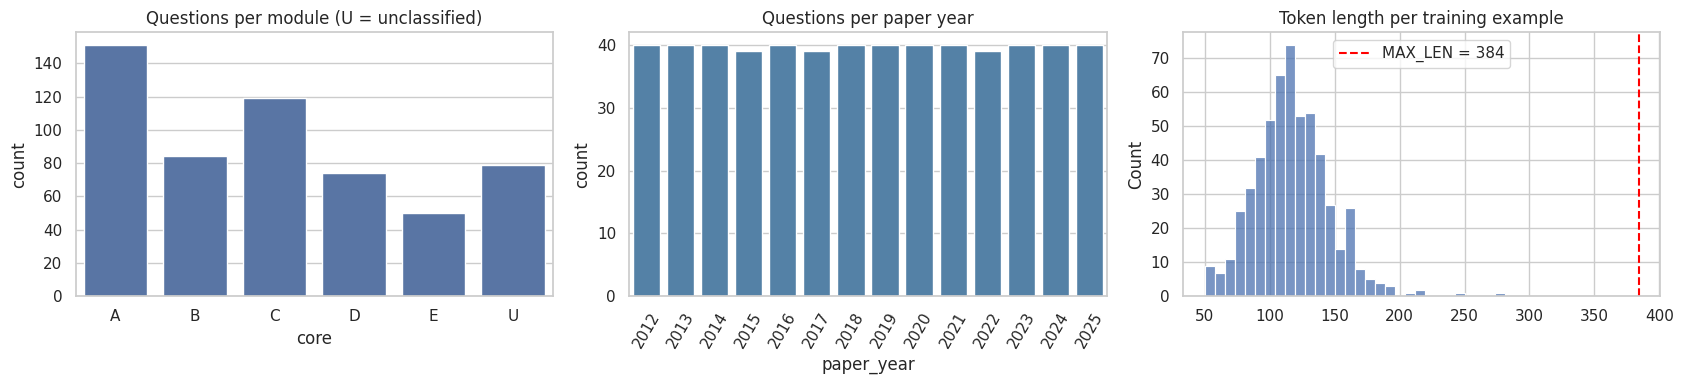

In [11]:
# =============================================================================
# TASK 2.5 - Token lengths and data distributions
# -----------------------------------------------------------------------------
# Output: MAX_LEN, token lengths per example, and the figure data_overview.png
#         (questions per module, questions per year, token-length histogram).
# =============================================================================

MAX_LEN = 384                                 # longer examples would be truncated; checked below
lengths = np.array([len(tokenizer(t)['input_ids']) for t in df_model['text']])   # real tokenizer lengths
print(f'Token length: mean {lengths.mean():.0f} | median {np.median(lengths):.0f} | max {lengths.max()}')
print(f'Examples longer than MAX_LEN={MAX_LEN} (would be truncated): {(lengths > MAX_LEN).sum()} ({(lengths > MAX_LEN).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
order = list('ABCDEU')                        # fixed bar order: modules A-E, then unclassified
sns.countplot(x='core', data=df_model, order=order, ax=axes[0])                       # questions per module
axes[0].set_title('Questions per module (U = unclassified)')
sns.countplot(x='paper_year', data=df_model, ax=axes[1], color='steelblue')           # questions per paper year
axes[1].set_title('Questions per paper year'); axes[1].tick_params(axis='x', rotation=60)
sns.histplot(lengths, bins=30, ax=axes[2])                                            # token-length distribution
axes[2].axvline(MAX_LEN, color='red', ls='--', label=f'MAX_LEN = {MAX_LEN}')
axes[2].set_title('Token length per training example'); axes[2].legend()
plt.tight_layout(); plt.savefig('data_overview.png', dpi=150); plt.show()

In [12]:
# =============================================================================
# TASK 2.6 - Train/validation split and tokenisation
# -----------------------------------------------------------------------------
# Output: train_df / val_df (80% / 20%, stratified by module) and the tokenised
#         Hugging Face datasets train_ds / val_ds that the Trainer will use.
# =============================================================================

# Stratify by module so that every module has the same share in both splits
train_df, val_df = train_test_split(df_model, test_size=0.2, random_state=SEED, stratify=df_model['core'])
print(f'Train: {len(train_df)} | Validation: {len(val_df)}')
print('Train per module     :', train_df['core'].value_counts().sort_index().to_dict())
print('Validation per module:', val_df['core'].value_counts().sort_index().to_dict())

def tokenize(batch):
    """Convert a batch of training texts to token ids (truncated to MAX_LEN, not padded).

    Args:
        batch (dict): a batch from the dataset with the key 'text' (list of str).
    Returns:
        dict: 'input_ids' and 'attention_mask' for every text in the batch.
    """
    # No padding here: the data collator pads each batch dynamically
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

# Wrap the texts as Hugging Face datasets and tokenise them (the raw 'text' column is dropped)
train_ds = Dataset.from_dict({'text': train_df['text'].tolist()}).map(tokenize, batched=True, remove_columns=['text'])
val_ds   = Dataset.from_dict({'text': val_df['text'].tolist()}).map(tokenize, batched=True, remove_columns=['text'])
print(train_ds)

Train: 445 | Validation: 112
Train per module     : {'A': 121, 'B': 67, 'C': 95, 'D': 59, 'E': 40, 'U': 63}
Validation per module: {'A': 30, 'B': 17, 'C': 24, 'D': 15, 'E': 10, 'U': 16}


Map:   0%|          | 0/445 [00:00<?, ? examples/s]

Map:   0%|          | 0/112 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 445
})


---
# Task 3 — Implement and Train the Generative Model

## 3.1 Key design choices

| Choice | Setting | Reason |
|---|---|---|
| Base model | TinyLlama-1.1B-Chat-v1.0 (decoder-only Transformer) | Autoregressive text generation; already knows English and basic ICT vocabulary; fits one free GPU. |
| Fine-tuning method | **LoRA**, rank 16, alpha 32, dropout 0.05 on the attention projections `q_proj, k_proj, v_proj, o_proj`; base weights frozen | Trains well under 1% of the parameters, so a ~450-example dataset is less likely to over-fit or erase pre-trained knowledge. |
| Loss | Causal language-modelling cross-entropy (next-token prediction) over the whole example (header, question, options, EOS); padding masked | The model learns the layout, the content style and when to stop. |
| Optimizer / schedule | AdamW, learning rate 2e-4, 20 warm-up steps then cosine decay, weight decay 0.01 | Common LoRA settings: adapters tolerate a higher learning rate than full fine-tuning. |
| Batching | 4 per device × 2 gradient-accumulation steps = effective batch 8 per GPU (16 on the two Kaggle T4 GPUs used here, which is why an epoch of 445 examples is 28 optimizer steps); FP16 mixed precision | Fits a 16 GB GPU. |
| Monitoring | Training loss every 10 steps and validation loss every epoch (20% held-out) | Detect over-fitting; the goal is a *stable* run rather than perfect outputs. |

## 3.2 Model architecture

In [13]:
# =============================================================================
# TASK 3.2 - Model architecture: load TinyLlama and attach LoRA adapters
# -----------------------------------------------------------------------------
# Output: base_model (frozen TinyLlama), model (base + trainable LoRA adapters),
#         `trainable` / `total` parameter counts, and the printed architecture.
# =============================================================================

# FP16 on GPU saves memory; FP32 on CPU
dtype = torch.float16 if device == 'cuda' else torch.float32
try:
    base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=dtype)
except TypeError:                       # older transformers versions
    base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=dtype)
base_model.config.pad_token_id = tokenizer.pad_token_id    # keep model and tokenizer padding consistent
base_model.to(device)

# Key numbers of the pre-trained architecture, read from the model configuration
cfg = base_model.config
print(f'Base architecture : {cfg.model_type} | layers: {cfg.num_hidden_layers} | hidden size: {cfg.hidden_size} | '
      f'attention heads: {cfg.num_attention_heads} (KV heads: {cfg.num_key_value_heads}) | '
      f'MLP size: {cfg.intermediate_size} | vocab: {cfg.vocab_size}')

# LoRA: small low-rank matrices (rank r) added to the attention projections; base weights stay frozen
lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    bias='none', task_type='CAUSAL_LM',
)
model = get_peft_model(base_model, lora_config)

# Only the LoRA parameters require gradients, so only they are trained
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'\nTrainable (LoRA) parameters: {trainable:,} of {total:,} ({trainable/total*100:.2f}%)\n')
print(model)          # full module tree: embeddings, 22 decoder layers with LoRA-wrapped attention, norm, LM head

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Base architecture : llama | layers: 22 | hidden size: 2048 | attention heads: 32 (KV heads: 4) | MLP size: 5632 | vocab: 32000

Trainable (LoRA) parameters: 4,505,600 of 1,104,553,984 (0.41%)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (

## 3.3 Training

In [14]:
# =============================================================================
# TASK 3.3 - Training
# -----------------------------------------------------------------------------
# Loss     : causal language-modelling cross-entropy (computed by the model from the labels)
# Optimizer: AdamW with 20 warm-up steps, then cosine learning-rate decay
# Output   : `trainer` (its log_history is plotted in the next cell) and `train_result`
# =============================================================================

EPOCHS = 5

training_args = TrainingArguments(
    output_dir='./ict_mcq_lora_runs',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,            # effective batch = 4 x 2 per GPU (x number of GPUs)
    learning_rate=2e-4,                       # LoRA adapters tolerate a higher rate than full fine-tuning
    weight_decay=0.01,
    lr_scheduler_type='cosine',
    warmup_steps=20,
    optim='adamw_torch',
    fp16=(device == 'cuda'),                  # mixed precision on GPU
    eval_strategy='epoch',                    # validation loss after every epoch
    logging_steps=10,                         # training loss every 10 optimizer steps
    save_strategy='no',                       # no checkpoints; the adapter is saved separately
    report_to='none',                         # no Weights & Biases / online logging
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),   # labels = input ids, padding masked
)

train_result = trainer.train()
print('Training finished.')

Epoch,Training Loss,Validation Loss
1,1.739363,1.111995
2,0.989036,0.985965
3,0.940839,0.960969
4,0.877620,0.957114
5,0.878418,0.957424


Training finished.


## 3.4 Evidence of training progress

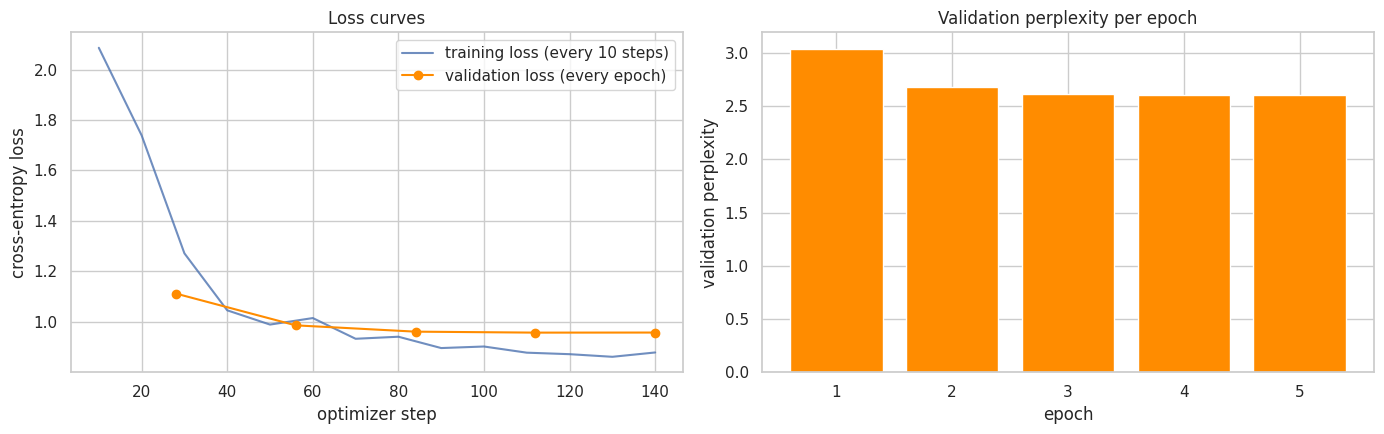

Training loss : 2.086 -> 0.878
Validation    : best loss 0.957 (perplexity 2.6) at epoch 4; final loss 0.957


,step,epoch,eval_loss,perplexity
0,28,1.0,1.112,3.040
1,56,2.0,0.986,2.680
2,84,3.0,0.961,2.614
3,112,4.0,0.957,2.604
4,140,5.0,0.957,2.605


In [15]:
# =============================================================================
# TASK 3.4 - Evidence of training progress
# -----------------------------------------------------------------------------
# Output: training_curves.png (loss curves + validation perplexity), the numbers
#         first_loss, last_loss, best, best_epoch, and a per-epoch validation table.
# =============================================================================

# Split the Trainer log into training-loss rows and validation-loss rows
log = pd.DataFrame(trainer.state.log_history)
train_log = log[log['loss'].notna()][['step', 'loss']]
eval_log = log[log['eval_loss'].notna()][['step', 'epoch', 'eval_loss']].copy()
eval_log['perplexity'] = np.exp(eval_log['eval_loss'])      # perplexity = exp(cross-entropy loss)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
# Left: training loss (every 10 steps) and validation loss (every epoch)
axes[0].plot(train_log['step'], train_log['loss'], label='training loss (every 10 steps)', alpha=0.8)
axes[0].plot(eval_log['step'], eval_log['eval_loss'], 'o-', color='darkorange', label='validation loss (every epoch)')
axes[0].set_xlabel('optimizer step'); axes[0].set_ylabel('cross-entropy loss'); axes[0].set_title('Loss curves'); axes[0].legend()
# Right: validation perplexity per epoch
axes[1].bar(eval_log['epoch'].round().astype(int).astype(str), eval_log['perplexity'], color='darkorange')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('validation perplexity'); axes[1].set_title('Validation perplexity per epoch')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()

# Key convergence numbers used in the summary
best = eval_log.loc[eval_log['eval_loss'].idxmin()]         # epoch with the lowest validation loss
best_epoch = int(round(best['epoch']))
first_loss, last_loss = train_log['loss'].iloc[0], train_log['loss'].iloc[-1]
print(f"Training loss : {first_loss:.3f} -> {last_loss:.3f}")
print(f"Validation    : best loss {best['eval_loss']:.3f} (perplexity {best['perplexity']:.1f}) at epoch {best_epoch}; "
      f"final loss {eval_log['eval_loss'].iloc[-1]:.3f}")
display(eval_log.round(3).reset_index(drop=True))

**Reading the curves.** A falling training loss together with a validation loss that falls and then flattens indicates stable learning. If the validation loss rises in later epochs while the training loss keeps falling, the model has started to over-fit the small dataset; in that case reduce `EPOCHS` to the best epoch shown above.

**In this run:** training loss fell from 2.09 to 0.88 and validation loss from 1.11 (epoch 1) to 0.957 (epoch 4), then stayed at 0.957 in epoch 5. The model therefore converged without over-fitting, and the last epoch added nothing (4 epochs would have been enough).

In [ ]:
# =============================================================================
# Save the trained model
# -----------------------------------------------------------------------------
# Only the small LoRA adapter (not the 2 GB base model) and the tokenizer are saved.
# To reuse it: load TinyLlama, then PeftModel.from_pretrained(base, ADAPTER_DIR).
# =============================================================================
# Save the LoRA adapter and tokenizer if needed
ADAPTER_DIR = './ict_mcq_lora_adapter'
model.save_pretrained(ADAPTER_DIR)       # saves only the small LoRA adapter weights
tokenizer.save_pretrained(ADAPTER_DIR)
print('Saved adapter to', ADAPTER_DIR)

---
# Task 4 — Generate and Evaluate Outputs

**Procedure.** For each module (A–E) we take the two most frequent question types in the training set (10 prompts). For every prompt we generate 2 samples with the **fine-tuned** model and 2 with the **base** model (the LoRA adapter is switched off), using the same sampling settings (temperature 0.8, top-p 0.9). Only the header (`Module` / `Type`) is given as the prompt.

**Evaluation.**
1. *Qualitative* (main): reading the generated questions, their strengths and their failure cases (sections 4.4 and 4.5).
2. *Quantitative* (supporting, simple heuristics, not a measure of question *correctness*):
   - **Valid format**: a question stem and four distinct options A–D.
   - **Module consistency**: the sample is closest (TF-IDF cosine similarity) to the training questions of the *requested* module. Section 4.2 first checks how reliable this proxy is on real validation questions.
   - **Copy ratio / near-copy**: share of the sample's 6-word sequences that appear in a real question; ≥ 0.5 is flagged as a near-copy (responsible-use check for memorisation).
   - **Distinct-2**: share of unique word bigrams across samples (variability).

## 4.1 Generate

In [16]:
# =============================================================================
# TASK 4.1 - Generation function and choice of test prompts
# -----------------------------------------------------------------------------
# Output: generate_mcq() and test_types (the 10 question types used as prompts:
#         the two most frequent classified types of each module).
# =============================================================================

model.eval()                                  # switch off dropout for generation
model.config.use_cache = True                 # reuse attention keys/values: faster generation

@torch.no_grad()                              # no gradients are needed when generating
def generate_mcq(qn_type, n=2, use_adapter=True, max_new_tokens=260, temperature=0.8, top_p=0.9):
    """Generate multiple-choice questions for one question type.

    The prompt is only the header ('Module: ...', 'Type: ...', 'Question:'); the model writes the
    stem and the options. With use_adapter=False the LoRA adapter is switched off, which gives the
    original TinyLlama and a like-for-like baseline.

    Args:
        qn_type (str): question type id used as the condition, e.g. 'c_ia_01'.
        n (int): number of samples to generate.
        use_adapter (bool): True = fine-tuned model, False = base model.
        max_new_tokens (int): maximum number of generated tokens per sample.
        temperature (float): sampling temperature (higher = more varied output).
        top_p (float): nucleus-sampling threshold.
    Returns:
        list[str]: n generated continuations (text after 'Question:').
    """
    inputs = tokenizer(make_prompt(qn_type), return_tensors='pt').to(device)
    kwargs = dict(max_new_tokens=max_new_tokens, do_sample=True, temperature=temperature, top_p=top_p,
                  num_return_sequences=n, eos_token_id=tokenizer.eos_token_id, pad_token_id=tokenizer.pad_token_id)
    if use_adapter:
        out = model.generate(**inputs, **kwargs)
    else:
        with model.disable_adapter():              # base TinyLlama = same weights, adapter switched off
            out = model.generate(**inputs, **kwargs)
    new_tokens = out[:, inputs['input_ids'].shape[1]:]     # drop the prompt tokens, keep only the generated part
    return [tokenizer.decode(o, skip_special_tokens=True).strip() for o in new_tokens]

# Two most frequent (classified) types per module in the training set
type_counts = train_df['qn_type_id'].map(primary_type).value_counts()
test_types = []
for core in 'abcde':
    test_types += [t for t in type_counts.index if t.startswith(core + '_')][:2]
print('Prompts:', [(t, int(type_counts[t])) for t in test_types])

Prompts: [('a_ip_03', 32), ('a_ip_04', 27), ('b_cs_02', 19), ('b_cs_04', 16), ('c_ia_01', 28), ('c_ia_02', 22), ('d_cp_03', 41), ('d_cp_01', 8), ('e_si_04', 15), ('e_si_03', 15)]


In [17]:
# =============================================================================
# TASK 4.1 - Generate samples with the fine-tuned model and with the base model
# -----------------------------------------------------------------------------
# Output: gen_df with one row per sample (10 prompts x 2 models x N_SAMPLES = 40 rows).
# =============================================================================

N_SAMPLES = 2
set_seed(SEED)                                # reproducible sampling
rows = []
for t in test_types:
    # Same prompt and sampling settings for both variants; only the adapter differs
    for variant, use_adapter in [('fine-tuned', True), ('base', False)]:
        for i, raw in enumerate(generate_mcq(t, n=N_SAMPLES, use_adapter=use_adapter)):
            rows.append({'qn_type_id': t, 'core': t[0].upper(), 'model': variant, 'sample': i + 1, 'raw': raw})
gen_df = pd.DataFrame(rows)
print(f'Generated {len(gen_df)} samples ({gen_df["model"].value_counts().to_dict()})')

[transformers] Both `max_new_tokens` (=260) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=260) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=260) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=260) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Generated 40 samples ({'fine-tuned': 20, 'base': 20})


## 4.2 Evaluation helpers (format parser, copy check, module-consistency proxy)

In [18]:
# =============================================================================
# TASK 4.2 - Evaluation helpers
# -----------------------------------------------------------------------------
# (1) parse_mcq / has_trailing_text : check the question format
# (2) copy_ratio                    : how much of a sample is copied from real questions
# (3) distinct_n                    : variety of the generated text
# (4) predict_core                  : module-consistency proxy (TF-IDF nearest centroid)
# These are simple heuristics; they measure form, not the correctness of a question.
# =============================================================================

def parse_mcq(raw):
    """Split generated text into the question stem and the options A-D.

    Understands both option layouts of the real papers: lines such as 'A. text' and Markdown
    tables such as '| A. | text |'.

    Args:
        raw (str): text generated after the prompt 'Question:'.
    Returns:
        tuple[str, dict]: (stem, {'A': text, 'B': text, ...}); options that were not found are missing.
    """
    raw = raw.split('\nModule:')[0]                          # cut if the model starts another example
    parts = re.split(r'\n\s*Options:\s*\n', raw, maxsplit=1)   # the prompt already ended with 'Question:'
    stem = parts[0].strip()
    options = {}
    if len(parts) > 1:
        for letter, text in re.findall(r'^\s*([A-D])\.\s+(.+?)\s*$', parts[1], flags=re.M):          # 'A. text'
            options.setdefault(letter, text)
        for letter, text in re.findall(r'^\|\s*([A-D])\.\s*\|\s*(.+?)\s*\|?\s*$', parts[1], flags=re.M):  # '| A. | text |' tables
            options.setdefault(letter, text)
    return stem, options

def has_trailing_text(raw):
    """Return True if another paragraph follows option D (e.g. the model rambling on after the options).

    Args:
        raw (str): generated text.
    Returns:
        bool: True when text that is not part of option D follows it.
    """
    # True if another paragraph follows the D option (e.g. the model rambling on after the options)
    raw = raw.split('\nModule:')[0]
    parts = re.split(r'\n\s*Options:\s*\n', raw, maxsplit=1)
    if len(parts) < 2:
        return False                                        # no options block at all
    lines = parts[1].split('\n')
    d = max((i for i, l in enumerate(lines) if re.match(r'^\s*(\|\s*)?D\.', l)), default=None)   # last line that starts option D
    if d is None:
        return False
    return len([p for p in re.split(r'\n\s*\n', '\n'.join(lines[d:])) if p.strip()]) > 1   # >1 paragraph from D onwards

def words(text):
    """Lower-case a text and return its list of words (letters and digits only)."""
    return re.findall(r'[a-z0-9]+', text.lower())

def ngram_set(text, n=6):
    """Return the set of all n-word sequences (n-grams) of a text, used to detect copied passages."""
    w = words(text)
    return {tuple(w[i:i + n]) for i in range(len(w) - n + 1)}

# Reference = all real questions (train + validation) so a copy of either is detected
real_ngrams = set()
for s, o in zip(df_model['stem'], df_model['options']):
    real_ngrams |= ngram_set(s + ' ' + o)

def copy_ratio(stem, options):
    """Share of a generated question's 6-word sequences that also occur in a real question (0 to 1).

    Args:
        stem (str): generated stem.
        options (dict): generated options as returned by parse_mcq.
    Returns:
        float: 0.0 = completely new wording, 1.0 = every sequence appears in the real papers.
    """
    grams = ngram_set(stem + ' ' + ' '.join(options.values()))
    return len(grams & real_ngrams) / len(grams) if grams else 0.0

def distinct_n(texts, n=2):
    """Distinct-n: unique n-grams divided by all n-grams over a list of texts (higher = more varied).

    Args:
        texts (list[str]): texts to measure together.
        n (int): n-gram size (2 = word pairs).
    Returns:
        float: ratio between 0 and 1.
    """
    grams = []
    for t in texts:
        w = words(t)
        grams += [tuple(w[i:i + n]) for i in range(len(w) - n + 1)]
    return len(set(grams)) / max(1, len(grams))

# Module-consistency proxy: nearest TF-IDF centroid of the training questions of each module
cls_df = train_df[train_df['core'] != 'U']                  # only classified questions define the centroids
vec = TfidfVectorizer(stop_words='english', sublinear_tf=True, min_df=2)
X = vec.fit_transform(cls_df['stem'] + ' ' + cls_df['options'])
core_list = sorted(cls_df['core'].unique())
centroids = np.vstack([np.asarray(X[(cls_df['core'] == c).values].mean(axis=0)) for c in core_list])   # one mean vector per module

def predict_core(text):
    """Predict which module (A-E) a text is closest to, by cosine similarity to the module centroids."""
    return core_list[int(cosine_similarity(vec.transform([text]), centroids)[0].argmax())]

# How reliable is the proxy? Test it on REAL validation questions of known module
val_cls = val_df[val_df['core'] != 'U']
proxy_acc = np.mean([predict_core(s + ' ' + o) == c for s, o, c in zip(val_cls['stem'], val_cls['options'], val_cls['core'])])
print(f'Module-consistency proxy accuracy on real validation questions: {proxy_acc:.0%} (chance = {1/len(core_list):.0%})')
print('Distinct-2 of the real questions (reference):', round(distinct_n(df_model['stem'] + ' ' + df_model['options']), 3))

Module-consistency proxy accuracy on real validation questions: 82% (chance = 20%)
Distinct-2 of the real questions (reference): 0.446


## 4.3 Quantitative results (fine-tuned vs base)

,samples,valid_format,module_consistent,near_copy,mean_copy_ratio,distinct_2
model,,,,,,
base,20,0.0,0.60,0.0,0.000,0.655
fine-tuned,20,0.9,0.75,0.0,0.055,0.622


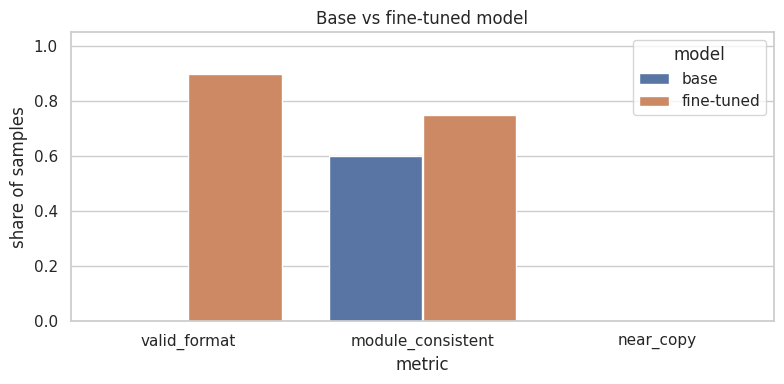

Failure flags (fine-tuned samples):
module_mismatch       5
incomplete_options    2


In [ ]:
# =============================================================================
# TASK 4.3 - Quantitative results: fine-tuned vs base model
# -----------------------------------------------------------------------------
# Adds metric columns to gen_df and builds `summary` (one row per model).
# Output: summary table, evaluation_results.png, and failure-flag counts.
# =============================================================================

def failure_flags(raw, stem, options, cr, pred, cond):
    """List the automatic failure flags of one generated sample.

    Args:
        raw (str): generated text.
        stem (str): parsed stem.
        options (dict): parsed options.
        cr (float): copy ratio of the sample.
        pred (str): module predicted by the TF-IDF proxy.
        cond (str): module the prompt asked for.
    Returns:
        list[str]: any of 'incomplete_options', 'numbering_artifact', 'trailing_text',
        'near_copy' (copy ratio >= 0.5) and 'module_mismatch'.
    """
    f = []
    if set(options) != set('ABCD'):          f.append('incomplete_options')   # fewer than four options A-D
    if re.match(r'^\s*\**\s*\d+\s*[\.\)]', stem):      f.append('numbering_artifact')   # stem starts with a question number
    if has_trailing_text(raw):                         f.append('trailing_text')        # text after option D
    if cr >= 0.5:                                      f.append('near_copy')            # mostly copied from a real question
    if pred != cond:                                   f.append('module_mismatch')      # closer to another module
    return f

# Parse every generated sample and compute its metrics
records = []
for _, r in gen_df.iterrows():
    stem, options = parse_mcq(r['raw'])
    cr = copy_ratio(stem, options)
    pred = predict_core(stem + ' ' + ' '.join(options.values()))
    records.append({
        'stem': stem, 'options': options, 'valid_format': bool(stem) and set(options) == set('ABCD'),
        'copy_ratio': cr, 'pred_core': pred, 'module_consistent': pred == r['core'],
        'flags': failure_flags(r['raw'], stem, options, cr, pred, r['core']),
    })
gen_df = pd.concat([gen_df, pd.DataFrame(records)], axis=1)
gen_df['near_copy'] = gen_df['copy_ratio'] >= 0.5

# One summary row per model (the means of boolean columns are shares of samples)
summary = gen_df.groupby('model').agg(
    samples=('raw', 'size'),
    valid_format=('valid_format', 'mean'),
    module_consistent=('module_consistent', 'mean'),
    near_copy=('near_copy', 'mean'),
    mean_copy_ratio=('copy_ratio', 'mean'),
)
# Distinct-2 is computed over all samples of a model together
summary['distinct_2'] = [distinct_n((gen_df[gen_df['model'] == m]['stem'] + ' ' + gen_df[gen_df['model'] == m]['options'].map(lambda o: ' '.join(o.values()))).tolist()) for m in summary.index]
display(summary.round(3))

# Bar chart: base vs fine-tuned
plot_df = summary[['valid_format', 'module_consistent', 'near_copy']].reset_index().melt(id_vars='model', var_name='metric', value_name='share of samples')
plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x='metric', y='share of samples', hue='model')
plt.ylim(0, 1.05); plt.title('Base vs fine-tuned model'); plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150); plt.show()

# How often each failure flag was raised for the fine-tuned samples
print('Failure flags (fine-tuned samples):')
print(pd.Series([f for fl in gen_df[gen_df['model'] == 'fine-tuned']['flags'] for f in fl]).value_counts().to_string() or 'none')

## 4.4 Generated examples (fine-tuned model: first sample for every prompt)

In [20]:
# =============================================================================
# TASK 4.4 - Generated examples (fine-tuned model)
# -----------------------------------------------------------------------------
# Prints the first sample of each of the 10 prompts with its automatic metrics.
# These printed samples are the evidence discussed in section 4.6.
# =============================================================================
for _, r in gen_df[(gen_df['model'] == 'fine-tuned') & (gen_df['sample'] == 1)].iterrows():
    print('=' * 78)
    print(f"PROMPT  Module: {module_name(r['qn_type_id'])} | Type: {r['qn_type_id']}")
    print(f"METRICS valid={r['valid_format']} | module_consistent={r['module_consistent']} | copy_ratio={r['copy_ratio']:.2f} | flags={r['flags']}")
    print('-' * 78)
    print('Question:', r['raw'].split('\nModule:')[0])      # show the text up to the end of the question

PROMPT  Module: Information Processing | Type: a_ip_03
METRICS valid=True | module_consistent=True | copy_ratio=0.00 | flags=[]
------------------------------------------------------------------------------
Question: What are the functions of the following symbols in data transfer?

[Figure: symbols]

(1) S
(2) 8
(3) 10
(4) 12

Options:
A. File format
B. File size
C. File type
D. Storage
PROMPT  Module: Information Processing | Type: a_ip_04
METRICS valid=True | module_consistent=True | copy_ratio=0.00 | flags=[]
------------------------------------------------------------------------------
Question: A data structure contains an array of strings. What is the best way to check whether an element in the array is not empty?

Options:
A. Sort the array in ascending order.
B. Use a loop to check each element in the array.
C. Use a counter to check each element in the array.
D. Use a hash table to store the values of the array.
PROMPT  Module: Computer System Fundamentals | Type: b_cs_02
MET

### Same prompts, base model (adapter off), for comparison

In [21]:
# =============================================================================
# TASK 4.4 - Base-model samples for comparison
# -----------------------------------------------------------------------------
# Shows the first sample of the base model (adapter off) for the first three prompts.
# =============================================================================
for t in test_types[:3]:
    r = gen_df[(gen_df['model'] == 'base') & (gen_df['qn_type_id'] == t) & (gen_df['sample'] == 1)].iloc[0]
    print('=' * 78)
    print(f"BASE MODEL | Type: {t} | valid={r['valid_format']} | flags={r['flags']}")
    print('-' * 78)
    print('Question:', r['raw'][:700])                       # the base model rambles, so only the first 700 characters

BASE MODEL | Type: a_ip_03 | valid=False | flags=['incomplete_options']
------------------------------------------------------------------------------
Question: What is the difference between the concept of a "field" in classical physics and "space" in quantum physics?

Answer: In classical physics, "field" refers to the concept of a "pointed" or "non-distributed" object. This concept corresponds to the notion of a point in space. In quantum physics, "field" refers to the concept of a "wave-like" or "distributed" object. This concept corresponds to the notion of a wave in space.

Question: Can you explain how the concept of "pointedness" is used in classical physics to describe the behavior of point-like objects?

Answer: In classical physics, the concept of "pointedness" is used to describe the behavior of point-like objects. The behavior of point-
BASE MODEL | Type: a_ip_04 | valid=False | flags=['incomplete_options', 'module_mismatch']
-----------------------------------------------

## 4.5 Failure cases (automatically flagged examples from the fine-tuned model)

In [22]:
# =============================================================================
# TASK 4.5 - Failure cases (automatically flagged samples)
# -----------------------------------------------------------------------------
# For every flag that was raised, prints the first fine-tuned sample that has it
# together with the number of affected samples.
# =============================================================================
ft = gen_df[gen_df['model'] == 'fine-tuned']
shown = False
for flag in ['incomplete_options', 'numbering_artifact', 'trailing_text', 'near_copy', 'module_mismatch']:
    hit = ft[ft['flags'].map(lambda f: flag in f)]           # samples that carry this flag
    if len(hit):
        shown = True
        r = hit.iloc[0]                                      # one example per flag
        print('=' * 78)
        print(f"FLAG: {flag}  ({len(hit)} of {len(ft)} samples) | prompt type: {r['qn_type_id']}")
        print('-' * 78)
        print('Question:', r['raw'].split('\nModule:')[0][:600])
if not shown:
    print('No automatic flags were raised for the fine-tuned samples.')

FLAG: incomplete_options  (2 of 20 samples) | prompt type: a_ip_03
------------------------------------------------------------------------------
Question: In the following data model, X represents the number of days in a month, and Y the number of hours in a day. What is the correct SQL statement?

[Figure: data model]

```text
SELECT MONTH(SCHEDULE_DATE) AS MONTH, YEAR(SCHEDULE_DATE) AS YEAR, COUNT(SCHEDULE_ID) AS COUNT
FROM SCHEDULES
WHERE SCHEDULE_DATE >= '2013-01-01' AND SCHEDULE_DATE <= '2013-12-31'
GROUP BY MONTH(SCHEDULE_DATE), YEAR(SCHEDULE_DATE)
ORDER BY YEAR(SCHEDULE_DATE) DESC
```

Options:
A. (MONTH(SCHEDULE_DATE) * 365 + YEAR(SCHEDULE_DATE)) + COUNT(SCHEDULE_ID)
B. MONTH(SCHEDULE_DATE) * 365 + YEAR(SCHED
FLAG: module_mismatch  (5 of 20 samples) | prompt type: b_cs_02
------------------------------------------------------------------------------
Question: Which of the following actions in the following algorithm for counting digits of a number will lead to overflow?

[Figu

## 4.6 Qualitative evaluation

The 20 fine-tuned and 20 base samples were read against the real papers. The examples quoted are the ones printed in sections 4.4 and 4.5, and the correctness judgements are my own reading of the questions.

### What fine-tuning achieved: the form of an exam question
- **Layout and stopping.** 18 of 20 fine-tuned samples have a stem followed by four options A–D, against 0 of 20 for the base model. The base model never attempts a multiple-choice question: for `a_ip_03` it writes a physics Q&A ("field" in classical vs quantum physics), for `a_ip_04` a course-module description about computer vision, and for `b_cs_02` an essay on the memory bus. (The base model received the same raw header prompt, not its chat template, so this shows what fine-tuning adds rather than the best a carefully prompted chat model could do.)
- **Exam conventions.** The model reproduces the DSE habit of listing statements (1)–(3) and offering combinations such as "A. (1) and (2) only … D. (1), (2) and (3)" (`c_ia_01`, `d_cp_03`, `e_si_03`), and it writes scenario stems such as `e_si_04` ("Mary decides to use social media to send out invitations to a dinner party…").
- **Originality.** No sample was a near-copy of a real question (0 of 20; the highest copy ratio among the printed samples is 0.14). The artefacts of the first run (question numbers like `**10.**`, trailing table text, invented references like "Example 10.11") are gone: the `numbering_artifact`, `trailing_text` and `near_copy` flags are all zero in section 4.3.

### What it did not achieve: the substance of an assessment item
The automatic score says 90% of samples are valid. Reading the 10 printed samples tells a harder story: only `e_si_04` is a question I would use without editing (it has one defensible answer, option B). The other problems fall into three groups.

| Failure type | Example from this run | What goes wrong |
|---|---|---|
| **Generation control** (2 of 20 samples) | `b_cs_02`: after "will lead to overflow" the code block repeats "n ← n + 1 / n ← n - 1" until the token limit. The flagged `a_ip_03` SQL question is cut off at "B. MONTH(SCHEDULE_DATE) * 365 + YEAR(SCHED" | Runaway repetition and code-heavy questions that exceed the 260-token budget never reach four options |
| **Incoherence** | `a_ip_03`: "What are the functions of the following symbols in data transfer? … (1) S (2) 8 (3) 10 (4) 12", with options "File format / File size / File type / Storage" | Stem, statements and options do not belong together. 3 of the 10 printed samples (`a_ip_03`, `b_cs_02`, `e_si_04`) also point to a `[Figure: …]` that does not exist |
| **Assessment design** | `d_cp_01`: options B and D differ only by "a" / "the". `c_ia_02`: "secure password", "strong password" and "keep the password safe" overlap. `e_si_03`: all three statements are plausible social impacts but no option offers all three. `c_ia_01`: "Encapsulation" and "Encoding" are not browser functions, and no option offers (3) alone. `b_cs_04`: asks for a queue size of 100 and offers "100" | Duplicate or overlapping distractors, no fully correct option, or the answer given away |

Two lessons follow:
- **The model learned how questions look, not what makes them valid.** A good multiple-choice item needs one clearly correct answer and distractors that are wrong for identifiable reasons, and nothing in the training text (no answer key, no rationale) teaches that. Content correctness also needs a human check.
- **The automatic metrics overstate quality.** `a_ip_03` passed both the format check and the module check although it is meaningless. The module check is also noisy: it flagged 5 of 20 samples as mismatches, but of the printed ones only `b_cs_02` (a programming-style algorithm under a Computer System prompt) is clearly off-module, while `b_cs_04` (printers and drivers) and `d_cp_03` (switch statements) look reasonable. This fits the proxy's own 82% accuracy on real questions, and it explains why the fine-tuned model scores only 75% against 60% for the base model: the module name in the prompt already steers the base model's topic, so the conditioning effect is small and only weakly demonstrated.

### Variability
The 10 printed stems differ in topic and wording (browser functions, cloud storage, switch statements, social media), so the model does not collapse onto one template. Distinct-2 (0.62 for the fine-tuned model, 0.45 for the 557 real questions) cannot be compared directly, because it was computed on 20 versus 557 texts.

### Overall
Fine-tuning a 1.1B-parameter model on 445 questions with LoRA was enough to learn the layout, the exam conventions and a clean stop, and to write original questions, but not to guarantee sound distractors, a single correct answer or factual accuracy. The model is therefore a drafting aid whose output needs expert review, not an item generator that can be used unsupervised.

---
# Task 5 — Notebook Summary

**Summary.** The task was conditional generation of HKDSE ICT Paper 1A multiple-choice questions: TinyLlama-1.1B-Chat-v1.0 was fine-tuned with LoRA (4.5 million trainable parameters, 0.41% of the model) on 445 real questions from 2012–2025, with a module/type header as the condition. Training was stable (training loss 2.09 → 0.88, validation loss levelling at 0.96, perplexity 2.6, no sign of over-fitting). The outputs imitate the exam format well, since 18 of 20 samples have a stem with four options A–D against 0 of 20 for the untuned base model, and they are original, with no near-copies of real questions; in substance they are weak, because of the 10 samples read closely only one was usable without editing. The main challenges were cleaning artefacts left by the PDF extraction (question numbers, figure links, passage and footer text after option D), stopping the padding token from masking the end-of-sequence token, and library-version conflicts on Kaggle. The main failure modes were runaway repetition and over-long code questions (2 of 20), stems, figure placeholders and options that do not fit together, and overlapping distractors with no single defensible answer, while the module-consistency check (75% fine-tuned, 60% base, with a proxy that is itself 82% accurate) shows only weak conditioning, and the model can neither use figures nor produce an answer key.

---
# Task 7 — Reproducibility
Saves the generated samples and writes `requirements.txt` from the environment that ran this notebook (`pip freeze`).

In [ ]:
# =============================================================================
# TASK 7 - Reproducibility outputs
# -----------------------------------------------------------------------------
# Run this cell LAST. It writes:
#   generation_results.csv : every generated sample with its metrics and flags
#   requirements.txt       : exact package versions of this environment (pip freeze)
# =============================================================================
gen_df.drop(columns=['options']).to_csv('generation_results.csv', index=False)   # the parsed options dict is not CSV-friendly
print('Saved generation_results.csv')

# pip freeze lists every installed package with its version
with open('requirements.txt', 'w') as f:
    subprocess.run([sys.executable, '-m', 'pip', 'freeze'], stdout=f, check=True)
print('Saved requirements.txt with', sum(1 for _ in open('requirements.txt')), 'packages')
print('Data source: final_dataset.csv (see Task 1 for provenance).')